# **Методы на основе вмешательства: RISE implementation**

Привет, друзья! Добро пожаловать в новый туториал :) Он посвящен методу интерпретации на основе вмешательства — RISE.

#### **Мини-теория:**

Методы интерпретации на основе вмешательства основаны на идее ответа на вопрос: на вопрос:

> "Что произойдет с предсказанием модели если изменить или исключить отдельный признак?"

Cуть всех таких методов состоит в том, что мы изменяем входные данные $x$ по заранее определённому правилу, пропускаем изменное изображение $x'$ через модель и фиксируем дельту $\delta = f(x) - f(x')$ выхода модели. Отсюда, важность признака определяется через чувствительность модели к его изменениям.

Такие методы полезны в условиях, когда структура и параметры модели недоступны (например, работа через API). В отличие от градиентных подходов, они не требуют доступа к внутренним весам или производным модели.

Среди стандартных методов — Occlusion, Ablataion и Pertubation. А вот не совсем стандартный, но всё ещё часто встречающийся метод — **RISE** (*Randomized Input Sampling for Explanation of Black-box Models*), который в этом туториале и разберем.

**Его ключевые шаги:**

1. Генерируем случайные бинарные маски на изображение.  
2. Применяем эти маски и прогоняем через модель.  
3. Смотрим, как меняется вероятность предсказания интересующего класса.  
4. Собираем *важностную карту признаков* как средневзвешенную комбинацию масок.

Метод решает проблему корректной оценки множества всех бинарных масок (а для изображения $32 \times 32$ таких масок уже $2^{32\times 32}$), и именно это ключевая компонента, которую интересно пронаблюдать.

Приступим!


# **1. Импорт библиотек**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm


# **2. Данные и модель для демонстрации.**
Для демонстрации возьмем предобученную ResNet50 и картинку кошки. В прочем, вы можете подгрузить любое изображение и поработать с ним.

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


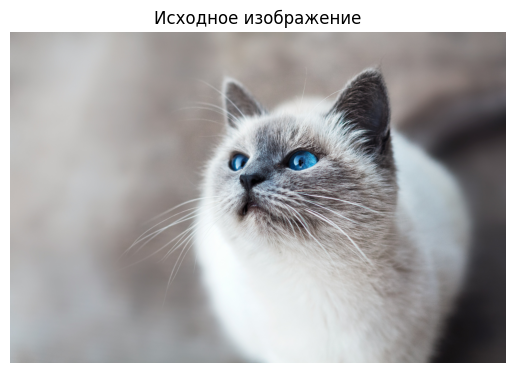

In [ ]:
# Загружаем модель
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.eval()

# Преобразования для картинки
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Загружаем картинку
import requests, io
url = "https://github.com/SadSabrina/XAI-open_materials/blob/38216bfee2a38c96b4f1d16460040cb89527c3fe/yolo_nas_cam_tutorial/coco_test/cat.jpg?raw=True"
img = Image.open(requests.get(url, stream=True).raw).convert("RGB")

x = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

plt.imshow(img)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


# **3. RISE: постановка и реализация.**

## **3.1. Постановка.**

Пусть:

- $f: I \to \mathbb{R}$ — модель-чёрный ящик, которая по изображению $I$ возвращает уверенность в целевом классе.  
- $\Lambda = \{1,\dots,H\} \times \{1,\dots,W\}$ — множество координат пикселей $\lambda$.  
- $M: \Lambda \to \{0,1\}$ — случайная бинарная маска с распределением $D$.  

Тогда важность пикселя $\lambda$ определяется как условное матожидание:

$$
Imp_{I,f}(\lambda) = \mathbb{E}_M \big[ f(I \odot M) \mid M(\lambda)=1 \big],
$$

где оператор $⊙$ обозначает покоординатное умножение (применение маски к изображению).

**Интуиция:** если сохранение пикселя $\lambda$ после маскирования существенно увеличивает вероятность целевого класса, то этот пиксель важен для прогноза.


Однако, даже для изображения $32 \times 32$ количество всех возможных масок равно $2^{32 \cdot 32}$, что вычислительно невозможно.  
Поэтому в RISE применяются два приёма:

1. **Переход к безусловному распределению масок.**  
   Условное матожидание разворачивается через формулу Байеса.

2. **Специальный способ маскирования с использованием билинейной интерполяции.**  
   Маски сначала генерируются в низком разрешении с заданной вероятностью сохранения пикселя,  
   а затем увеличиваются до размера изображения методом билинейной интерполяции.  
   Это сглаживает границы масок и делает объяснения более устойчивыми.


### **Hint 1. Развёртка через формулу Байеса**

Исходная формула:

$$
Imp_{I,f}(\lambda) = \mathbb{E}_M \big[ f(I \odot M) \mid M(\lambda)=1 \big]
= \sum_{m} f(I \odot m)\, P\!\big(M=m \mid M(\lambda)=1\big).
$$

Прямая работа с условной вероятностью неудобна, потому что она требует явно учитывать распределение $P[M=m | M(\lambda)=1]$. Поэтому авторы переходят к безусловному матожиданию, используя формулу Байеса:

$$
P(M=m \mid M(\lambda)=1) = \frac{P(M=m, M(\lambda)=1)}{P(M(\lambda)=1)}.
$$

Так как:

$$
P(M=m,\, M(\lambda)=1) =
\begin{cases}
0, & m(\lambda)=0, \\[6pt]
P(M=m), & m(\lambda)=1,
\end{cases}
$$

то нулевые слагаемые можно отбросить, а $m(\lambda)=1$ учесть явно. Получаем:

$$
Imp_{I,f}(\lambda) = \frac{1}{P[M(\lambda)=1]} \sum_{m} f(I \odot m)\, m(\lambda)\, P[M=m].
$$

Знаменатель $P[M(\lambda)=1] = \mathbb{E}[M]$, так как математическое ожидание индикаторной (либо 0, либо 1) случайной величины равно вероятности события, которое она описывает, то есть:
 $$\mathbb{E}[M(\lambda)] = 1 \cdot P(M(\lambda)=1) + 0 \cdot P(M(\lambda)=0) = P(M(\lambda)=1)$$


Далее, чтобы приближенно оценить сумму
$$\sum_{m} f(I \odot m)\, m(\lambda)\, P[M=m],$$
применяется метод Монте-Карло.  

Метод Монте-Карло позволяет приближённо вычислить математическое ожидание с помощью случайного сэмплирования. Формально, если $X$ — случайная величина, то её матожидание оценивается как

$$\mathbb{E}[X] \approx \frac{1}{N}\sum_{i=1}^N X_i,$$

где $X_1, \dots, X_N$ — независимые реализации $X$.


В нашем случае:  
- случайная величина — это $f(I \odot M)\, M(\lambda)$,  
- мы берём $N$ случайных масок $M_1, \dots, M_N$ из распределения $D$,  
- для каждой маски вычисляем предсказание модели $f(I \odot M_i)$,  
- умножаем его на $M_i(\lambda)$, чтобы учитывать вклад только тех масок, где пиксель $\lambda$ сохранён,  
- и усредняем полученные значения.


Таким образом, оценка важности пикселя с применением метода Монте-Карло имеет вид:

$$S_{I,f}^{MC}(\lambda) \approx \frac{1}{N \cdot \mathbb{E}[M]}
\sum_{i=1}^N f(I \odot M_i)\, M_i(\lambda).$$


Здесь:  
- нормировка $\tfrac{1}{N \cdot \mathbb{E}[M]}$ учитывает два фактора:  
  1. деление на $N$ соответствует усреднению по выборке,  
  2. деление на $\mathbb{E}[M] = P(M(\lambda)=1)$ корректирует результат с учётом вероятности сохранения пикселя;  
- $M_i(\lambda)$ — значение $i$-й маски в позиции $\lambda$:  
  - если пиксель $\lambda$ сохранён в маске $M_i$, то $M_i(\lambda)=1$,  
  - если замаскирован, то $M_i(\lambda)=0$.  

Таким образом, $M_i(\lambda)$ выступает в роли **индикатора**, который «включает» вклад $f(I \odot M_i)$ только в тех случаях, когда пиксель $\lambda$ действительно участвует в изображении.  



### **Hint 2. Сэмплирование масок с интерполяцией**

После перехода к безусловной вероятности не решает, однако, проблемы применимости метода Монте-Карло в пространстве всех масок $2^{H\times W}$. При условии стандартного input size $224\times 224$, прямое равновероятное сэмплирование пикселей даёт очень разные маски, которые, в свою очередь, даеют шумные оценки. Достичь устойчивости карты в таком случае возможно только при всё ещё большом количестве масок.

В качестве решения этой проблемы вводится **сэмплирование через интерполяцию**. А именно маски генерируются в 4 шага:

1. **Формирование малых бинарных масок.**  
   Генерируются маски размером $h \times w$.  
   Каждый элемент маски задаётся распределением Бернулли:  
   - значение $1$ с вероятностью $p$ (пиксель сохранён),  
   - значение $0$ с вероятностью $1-p$ (пиксель замаскирован).

2. **Апсемплинг с помощью билинейной интерполяции.**  
   Полученные малые маски увеличиваются до размера  $$(h+1) \cdot C_H \;\times\; (w+1) \cdot C_W,$$  
   где $C_H \times C_W = \lfloor H/h \rfloor \times \lfloor W/w \rfloor$ — размер ячейки после апсемплинга.  
   Благодаря билинейной интерполяции маска перестаёт быть строго бинарной и принимает значения в диапазоне $[0,1]$. Это сглаживает границы и делает итоговую карту важности более «непрерывной».

3. **Случайный сдвиг.**  
   Маска сдвигается на случайное число пикселей вдоль обеих координатных осей.  
   Такой шаг обеспечивает дополнительную вариативность и устраняет артефакты регулярной сетки.

4. **Обрезка (cropping).**  
   После сдвига берётся окно размера $H \times W$, совпадающее с размером исходного изображения.  
   Таким образом, маска приводится к нужным размерам для покоординатного умножения с $I$.

В результате маски получаются сглаженными, но при этом они всё ещё основаны на вероятностном распределении с параметром $p$.

Вот и всё, на этом теоретическая часть RISE окончена. Реализуем метод в коде.

### **3.2 Реализация**

По сути, для реализации необходимо три шага:

1. Сделать маски;
2. Применить маски к изображению;
3. Получить прогноз и усредить.

In [ ]:
# Генерация масок
# определяем размеры — размер исходный, размер пространства "мини-масок", размер интерполяции (последний — по формуле из статьи)

# исходный
_, C, H, W = x.shape
print(f'H:{H}\nW:{W}')

# размер квадратных мини-масок s = h = w
s = 7
print(f'Masks size:{s}x{s}')

# размер ячейки после апсэмплинга — то есть сколько пикселей "после" кодирует один исходный пиксель "до"
(C_H, C_W) = (H//s, W//s)
print(f'C_H, C_W: {(C_H, C_W)}')

# размер увеличенной маски — до обрезки
up_h, up_w = (s+1)*C_H, (s+1)*C_W
print(f'Up size: {up_h}x{up_w}')

H:224
W:224
Masks size:7x7
C_H, C_W: (32, 32)
Up size: 256x256


In [ ]:
# Генерируем N случайных масок с числами от 0 до 1 и бинаризуем их
N = 10
p = 0.5

grid = (torch.rand(N,1,s,s, device=x.device) < p).float()

# Расширяем маски на основе билинейной интерполяции
ups = F.interpolate(grid, size=(up_h, up_w), mode="bilinear", align_corners=False)

# Организуем случайные сдвиги и кроп
masks = torch.empty(N,1,H,W, device=x.device)
for i in range(N):
  dx = torch.randint(0, C_H, (1,), device=x.device).item() # сдвиг по x на случайное число от 0 до 32 (256-224)
  dy = torch.randint(0, C_W, (1,), device=x.device).item() # аналогично по y
  masks[i,0] = ups[i,0, dx:dx+H, dy:dy+W]

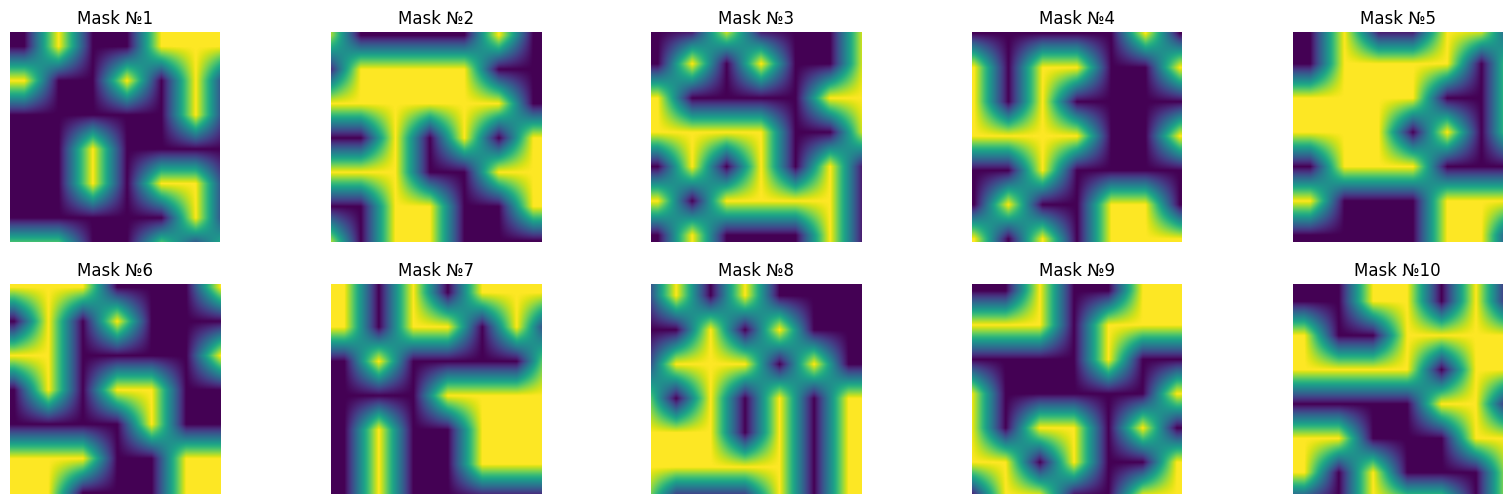

In [ ]:
# Посмотрим, что вышло
masks_arr = masks.numpy().reshape((10, 224, 224))

fig, ax = plt.subplots(2, 5, figsize=(20, 6))
axes = ax.flatten()

for i in range(10):
  axes[i].imshow(masks_arr[i])
  axes[i].set_title(f'Mask №{i+1}')
  axes[i].axis('off');

Теперь наложим маски на изображение. Наложение будем осуществлять elemt-wise умножением.

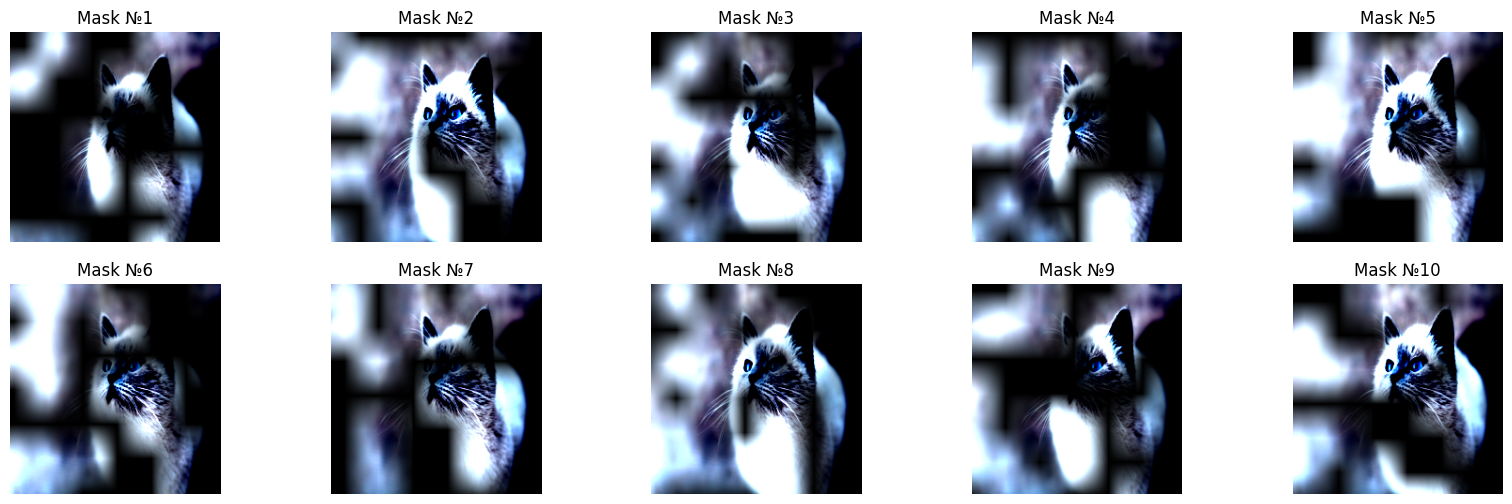

In [ ]:
x_as_arr = x.permute(0, 2, 3, 1)[0].numpy()

fig, ax = plt.subplots(2, 5, figsize=(20, 6))
axes = ax.flatten()

for i in range(10):
  axes[i].imshow(masks_arr[i][..., None] * x_as_arr)
  axes[i].set_title(f'Mask №{i+1}')
  axes[i].axis('off');

Осталось получить прогноз и усреднить.

In [ ]:
model(x).softmax(dim=1).argmax().item()

284

100%|██████████| 10/10 [00:01<00:00,  5.74it/s]


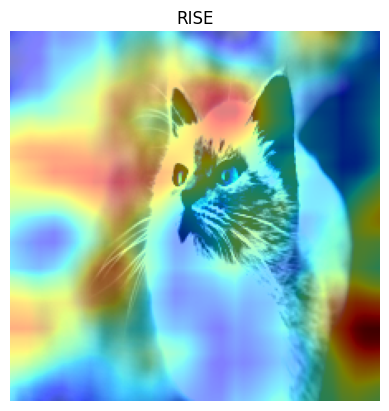

In [ ]:
scores = []
class_id = model(x).softmax(dim=1).argmax().item()


with torch.no_grad():
  for i in tqdm(range(0, N)):

    stack = masks[i] * x        # (B,1,H,W)*(1,C,H,W) -> (B,C,H,W)
    out = model(stack).softmax(dim=1)        # вероятности
    scores.append(out)          # (B,)

  scores = torch.cat(scores, dim=0)                # (N,)
  # Берём столбец интересующего класса: (N,)
  scores = scores[:, class_id]

  # Свернём MC-оценку: (H*W,) = (1 x N) @ (N x H*W)
  sal = torch.matmul(scores.view(1, N), masks.view(N, H * W)).view(H, W)
  sal = sal / (N * p)



plt.imshow(x[0].permute(1, 2, 0).numpy())
plt.imshow(sal.cpu(), cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("RISE")
plt.show()


Теперь обернем всё в функцию и построим карту с большим количеством масок.

In [ ]:
def RISE(model, x, N, s, p, class_id):
  model.eval()

  if class_id is None:
    class_id = model(x).softmax(dim=1).argmax().item()
    print(f'Selected class: {class_id}')

  # sizes
  _, C, H, W = x.shape
  (C_H, C_W) = (H//s, W//s)
  up_h, up_w = (s+1)*C_H, (s+1)*C_W

  grid = (torch.rand(N,1,s,s, device=x.device) < p).float()
  ups = F.interpolate(grid, size=(up_h, up_w), mode="bilinear", align_corners=False)

  # shifts and crop
  masks = torch.empty(N,1,H,W, device=x.device)
  for i in range(N):
    dx = torch.randint(0, C_H, (1,), device=x.device).item() # сдвиг по x на случайное число от 0 до 32 (256-224)
    dy = torch.randint(0, C_W, (1,), device=x.device).item() # аналогично по y
    masks[i,0] = ups[i,0, dx:dx+H, dy:dy+W]

  # scores
  scores = []
  with torch.no_grad():
    for i in tqdm(range(0, N)):
      stack = masks[i] * x        # (B,1,H,W)*(1,C,H,W) -> (B,C,H,W)
      out = model(stack).softmax(dim=1)        # вероятности
      scores.append(out)          # (B,)

  scores = torch.cat(scores, dim=0)
  # class_id scores
  scores = scores[:, class_id]

  # Agg
  sal = torch.matmul(scores.view(1, N), masks.view(N, H * W)).view(H, W)
  sal = sal / (N * p)

  return sal


In [ ]:
saliency_map_RISE1000 = RISE(model, x, 1000, 7, 0.5, None)

Selected class: 284


100%|██████████| 1000/1000 [03:13<00:00,  5.16it/s]


In [ ]:
saliency_map_RISE100 = RISE(model, x, 100, 7, 0.5, None)
saliency_map_RISE10 = RISE(model, x, 10, 7, 0.5, None)

Selected class: 284


100%|██████████| 100/100 [00:20<00:00,  4.77it/s]


Selected class: 284


100%|██████████| 10/10 [00:01<00:00,  5.51it/s]


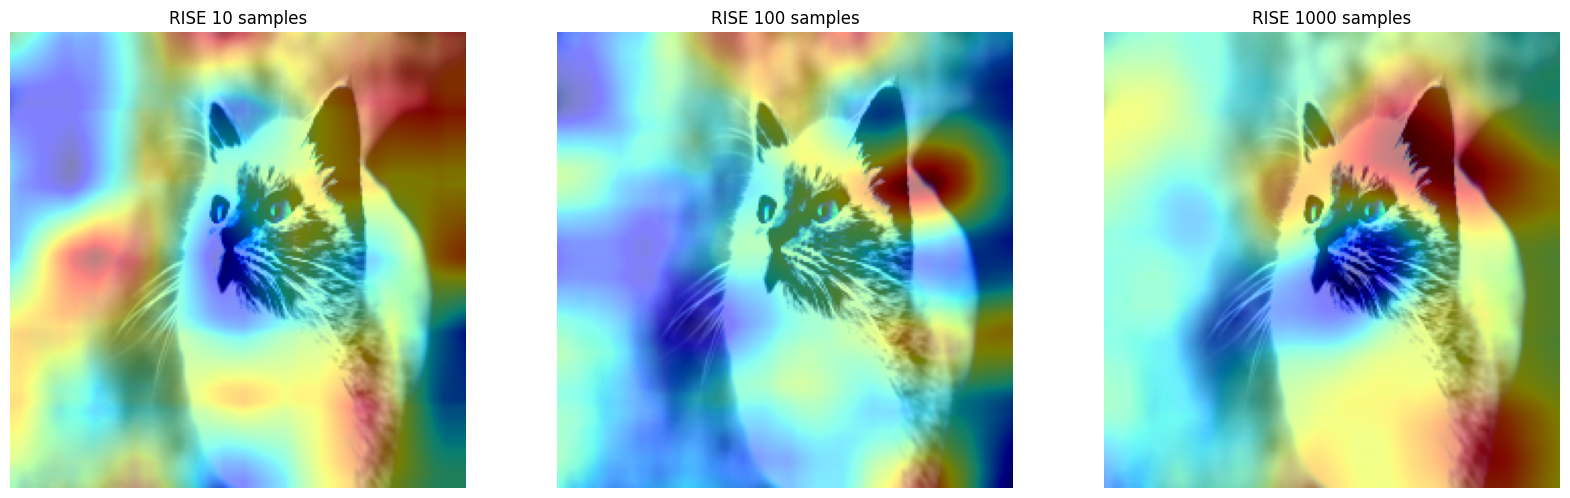

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

for i, map in enumerate([saliency_map_RISE10, saliency_map_RISE100, saliency_map_RISE1000]):
  ax[i].imshow(x[0].permute(1, 2, 0).numpy())
  ax[i].imshow(map.cpu(), cmap="jet", alpha=0.5)
  ax[i].axis("off")
  ax[i].set_title(f"RISE 10{'0'*i} samples")

plt.show()

Как видите, ручная реализация остается чувствительной к количеству наблюдений и их всё ещё необходимо достаточно много.

На этом, туториал завершается. Вы молодцы, если дошли до конца. В этом туториале мы разобрали применение метода **RISE** для интерпретации. Для этого:

* познакомились с идеей perturbation-based методов и формулировкой RISE через условное матожидание;
* аккуратно вывели математическую постановку и показали переход через формулу Байеса;
* реализовали алгоритм генерации случайных масок и обсудили трюк с билинейной интерполяцией;
* собрали Monte-Carlo аппроксимацию и построили карты важности для конкретного класса;
* визуализировали результаты и убедились, что метод работает даже для полностью «чёрных ящиков».

RISE позволяет получать интерпретации без доступа к весам и градиентам модели, что делает его универсальным инструментом. Однако стоит помнить, что качество карт важности зависит от числа сгенерированных масок и параметров распределения (например, вероятности сохранения пикселя). Попробуйте поэкспериментировать с параметрами и сравнить полученные карты с другими методами (например, [CAM](https://github.com/SadSabrina/XAI-open_materials/tree/main/CAM_yt), по которыму тоже есть туториал).



### **Основные материалы туториала:**
[1](https://arxiv.org/abs/1806.07421) — оригинальная статья о RISE,  
[2](https://github.com/eclique/RISE) — официальный репозиторий.


### **Новые материалы:**
Следите за обновлениями в [дата-блоге](https://t.me/jdata_blog) и на [гитхаб](https://github.com/SadSabrina/XAI-open_materials/tree/main)!

Со всем самым добрым,  
Ваш Дата-автор.

---

### **Код на GitHub и другие материалы:**
[github](https://github.com/SadSabrina/XAI-open_materials/blob/main/RISE/RISE_tutorial_rus.ipynb)

Также приглашаю пройти мой [курс](https://stepik.org/a/198640) по методам explainable AI и, конечно, буду рада видеть в [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).


